# Ex 5 — Regression Analysis

**Dataset:** India Rental House Price (Delhi + Mumbai + Pune)  
**Target:** Price per Square Foot  
**Reg No:** URK24CS1021

In [1]:
print("URK24CS1021")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, root_mean_squared_error

sns.set_theme(style="whitegrid")
SEED = 1021

df = pd.read_csv("rental.csv")
df.head()

URK24CS1021


,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,SecurityDeposit,Status
0,1 RK Studio Apartment,400 sq ft,Kalkaji,Delhi,28.545561,77.254349,22000,INR,1.0,NaN,NaN,NaN,Posted a day ago,No Deposit,Furnished
1,1 RK Studio Apartment,400 sq ft,Mansarover Garden,Delhi,28.643259,77.132828,20000,INR,1.0,NaN,NaN,NaN,Posted 9 days ago,No Deposit,Furnished
2,2 BHK Independent Floor,500 sq ft,Uttam Nagar,Delhi,28.618677,77.053352,8500,INR,1.0,NaN,NaN,NaN,Posted 12 days ago,No Deposit,Semi-Furnished
3,3 BHK Independent House,"1,020 sq ft",Model Town,Delhi,28.712898,77.180000,48000,INR,3.0,NaN,NaN,NaN,Posted a year ago,No Deposit,Furnished
4,2 BHK Apartment,810 sq ft,Sector 13 Rohini,Delhi,28.723539,77.131424,20000,INR,2.0,NaN,NaN,NaN,Posted a year ago,No Deposit,Unfurnished


### What is actually in the file?

In [2]:
print("URK24CS1021")

df.shape, df['city'].value_counts().to_dict()

URK24CS1021


((13910, 15), {'Delhi': 5000, 'Mumbai': 4992, 'Pune': 3910, 'Hisar': 8})

In [3]:
print("URK24CS1021")

df.describe()

URK24CS1021


,latitude,longitude,price,numBathrooms,numBalconies,priceSqFt
count,13910.000000,13910.000000,1.391000e+04,13854.000000,5291.000000,0.0
mean,22.380579,74.710460,1.084971e+05,2.326765,1.840484,NaN
std,4.660315,2.181421,1.934349e+05,1.002262,0.703672,NaN
min,17.468220,18.497896,1.500000e+03,1.000000,1.000000,NaN
25%,18.611296,72.965080,1.800000e+04,2.000000,1.000000,NaN
50%,19.148081,73.895599,3.300000e+04,2.000000,2.000000,NaN
75%,28.553211,77.152527,9.000000e+04,3.000000,2.000000,NaN
max,31.106586,91.792137,3.010101e+06,10.000000,8.000000,NaN


### The target column is empty, so it has to be derived

In [4]:
print("URK24CS1021")

# priceSqFt exists as a column but not a single row has a value
df["priceSqFt"].notna().sum()

URK24CS1021


np.int64(0)

In [5]:
print("URK24CS1021")

# house_size is text: "1,020 sq ft"
df["size_sqft"] = pd.to_numeric(
    df["house_size"].str.replace(" sq ft", "", regex=False).str.replace(",", "", regex=False),
    errors="coerce")
df["price_per_sqft"] = df["price"] / df["size_sqft"]
df["price_per_sqft"].describe()

URK24CS1021


count    13910.000000
mean        47.436717
std         39.497297
min          4.000000
25%         20.588235
50%         32.941176
75%         62.500000
max        382.024843
Name: price_per_sqft, dtype: float64

### Features — and the one column that must not be a feature

In [6]:
print("URK24CS1021")

df["house_type"] = df["house_type"].str.strip()
df["bhk"] = df["house_type"].str.extract(r"^(\d+)").astype(float)
df["numBathrooms"] = df["numBathrooms"].fillna(df["numBathrooms"].median())
df["numBalconies"] = df["numBalconies"].fillna(0)
top_loc = df["location"].value_counts().head(30).index
df["loc_grp"] = np.where(df["location"].isin(top_loc), df["location"], "Other")
df["location"].nunique(), df["loc_grp"].nunique()

URK24CS1021


(702, 31)

In [7]:
print("URK24CS1021")

# price stays out: price_per_sqft = price / size, so price leaks the answer
X = pd.get_dummies(df[["size_sqft", "bhk", "numBathrooms", "numBalconies",
                       "Status", "city", "loc_grp"]], drop_first=True)
y = df["price_per_sqft"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X.shape

URK24CS1021


(13910, 39)

### One predictor vs all of them

In [8]:
print("URK24CS1021")

results = []

def score(name, model, Xtr, Xte):
    model.fit(Xtr, y_train)
    p = model.predict(Xte)
    results.append({"Technique": name, "R2 Score": r2_score(y_test, p),
                    "RMSE": root_mean_squared_error(y_test, p)})
    return model

simple = score("Simple Linear", LinearRegression(),
               X_train[["size_sqft"]], X_test[["size_sqft"]])
results[-1]

URK24CS1021


{'Technique': 'Simple Linear', 'R2 Score': 0.16092377957301796, 'RMSE': 35.80328721639977}

In [9]:
print("URK24CS1021")

multi = score("Multiple Linear", LinearRegression(), X_train, X_test)
results[-1]

URK24CS1021


{'Technique': 'Multiple Linear', 'R2 Score': 0.38369598685437256, 'RMSE': 30.68454541432781}

In [10]:
print("URK24CS1021")

pd.Series(multi.coef_, index=X.columns).sort_values(key=abs, ascending=False).head(5)

URK24CS1021


loc_grp_Kalyan West      -46.946344
loc_grp_Dombivali        -45.083870
loc_grp_Kharghar         -43.103472
loc_grp_Ghansoli         -38.509809
loc_grp_Mira Road East   -37.602841
dtype: float64

### Bending the line, then penalising it

In [11]:
print("URK24CS1021")

poly = score("Polynomial (deg 2)",
             make_pipeline(PolynomialFeatures(degree=2, include_bias=False),
                           LinearRegression()), X_train, X_test)
poly.named_steps["polynomialfeatures"].n_output_features_, results[-1]

URK24CS1021


(819, {'Technique': 'Polynomial (deg 2)', 'R2 Score': 0.3840450498235577, 'RMSE': 30.675854609679615})

In [12]:
print("URK24CS1021")

lasso = score("Lasso", make_pipeline(StandardScaler(), Lasso(alpha=0.1, max_iter=5000)),
              X_train, X_test)
(lasso.named_steps["lasso"].coef_ == 0).sum(), results[-1]

URK24CS1021


(np.int64(3), {'Technique': 'Lasso', 'R2 Score': 0.382703755541438, 'RMSE': 30.70923608778667})

In [13]:
print("URK24CS1021")

ridge = score("Ridge", make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
              X_train, X_test)
(ridge.named_steps["ridge"].coef_ == 0).sum(), results[-1]

URK24CS1021


(np.int64(0), {'Technique': 'Ridge', 'R2 Score': 0.3836958191429818, 'RMSE': 30.684549589335052})

### The comparison, built from the collected scores

In [14]:
print("URK24CS1021")

table = pd.DataFrame(results).set_index("Technique").round(4)
table

URK24CS1021


,R2 Score,RMSE
Technique,,
Simple Linear,0.1609,35.8033
Multiple Linear,0.3837,30.6845
Polynomial (deg 2),0.3840,30.6759
Lasso,0.3827,30.7092
Ridge,0.3837,30.6845


URK24CS1021


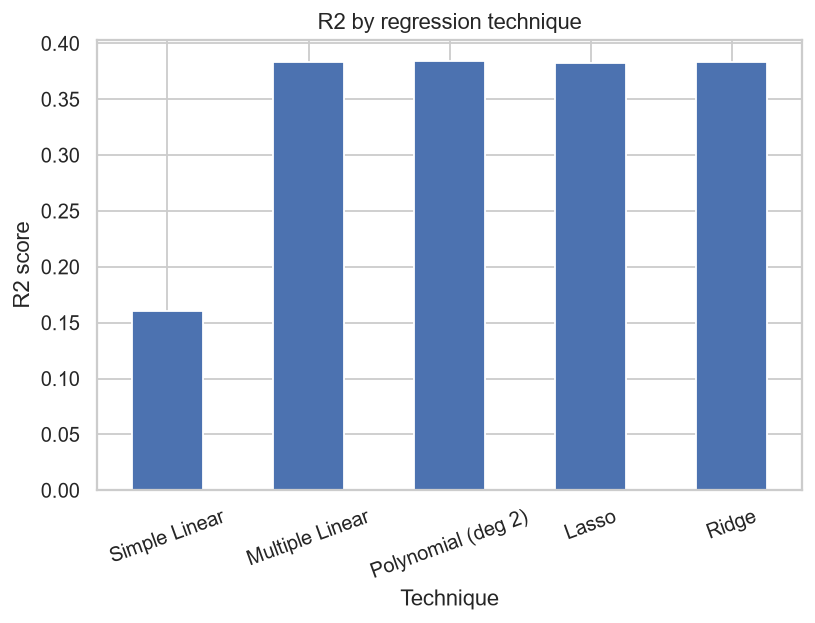

In [15]:
print("URK24CS1021")

table["R2 Score"].plot(kind="bar", color="#4C72B0", rot=20)
plt.ylabel("R2 score")
plt.title("R2 by regression technique")
plt.show()

URK24CS1021


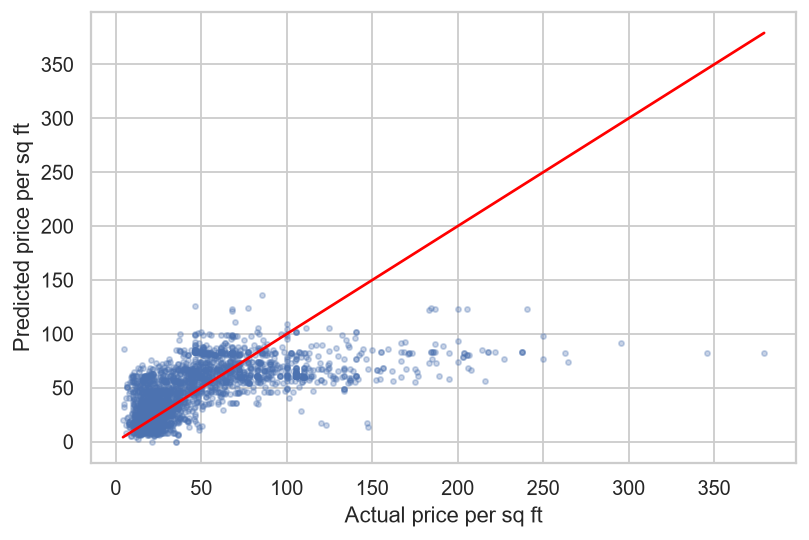

In [16]:
print("URK24CS1021")

pred = multi.predict(X_test)
plt.scatter(y_test, pred, s=8, alpha=0.3, color="#4C72B0")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color="red")
plt.xlabel("Actual price per sq ft")
plt.ylabel("Predicted price per sq ft")
plt.show()